Title: LEE_Comparison.ipynb

Purpose: Compare LEE events from ERA5 and SMARD

Author: Onno Nennecke on 10.07.2025 Modified: 10.09.2025

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# Import LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')

LEE_dat_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')

LEE_dat_7_sel = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_sel = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')


## Interesting stuff

It doesnt really make sense to compare these datasets too closely since the demand in the real world is mainly driven by political issues which shows in the data and leads to way less LEE events in the SMARD data from 2020 onwards.

You can however see that there are way less long events in the SMARD data (not sure why) 

In [3]:
# Cut all datasets to the first 5 years
LEE_dat = LEE_dat[LEE_dat['date_start'] < '2020-01-01']
LEE_dat_7 = LEE_dat_7[LEE_dat_7['date_start'] < '2020-01-01']
LEE_dat_14 = LEE_dat_14[LEE_dat_14['date_start'] < '2020-01-01']
LEE_dat_7_sel = LEE_dat_7_sel[LEE_dat_7_sel['date_start'] < '2020-01-01']
LEE_dat_14_sel = LEE_dat_14_sel[LEE_dat_14_sel['date_start'] < '2020-01-01']

In [15]:
# Select only ERA5 and SMARD data
LEE_dat_ERA5_week = LEE_dat[LEE_dat['ESM_run'] == 'ERA5_hist_week']
LEE_dat_ERA5_wwd = LEE_dat[LEE_dat['ESM_run'] == 'ERA5_hist_wwd']
LEE_dat_SMARD = LEE_dat[LEE_dat['ESM_run'] == 'SMARD_hist']

LEE_dat_7_ERA5_week = LEE_dat_7[LEE_dat_7['ESM_run'] == 'ERA5_hist_week']
LEE_dat_7_ERA5_wwd = LEE_dat_7[LEE_dat_7['ESM_run'] == 'ERA5_hist_wwd']
LEE_dat_7_SMARD = LEE_dat_7[LEE_dat_7['ESM_run'] == 'SMARD_hist']

LEE_dat_14_ERA5_week = LEE_dat_14[LEE_dat_14['ESM_run'] == 'ERA5_hist_week']
LEE_dat_14_ERA5_wwd = LEE_dat_14[LEE_dat_14['ESM_run'] == 'ERA5_hist_wwd']
LEE_dat_14_SMARD = LEE_dat_14[LEE_dat_14['ESM_run'] == 'SMARD_hist']

# Select only ERA5 and SMARD data for 7-day selection
LEE_dat_7_sel_ERA5_week = LEE_dat_7_sel[LEE_dat_7_sel['ESM_run'] == 'ERA5_hist_week']
LEE_dat_7_sel_ERA5_wwd = LEE_dat_7_sel[LEE_dat_7_sel['ESM_run'] == 'ERA5_hist_wwd']
LEE_dat_7_sel_SMARD = LEE_dat_7_sel[LEE_dat_7_sel['ESM_run'] == 'SMARD_hist']

# Select only ERA5 and SMARD data for 14-day selection
LEE_dat_14_sel_ERA5_week = LEE_dat_14_sel[LEE_dat_14_sel['ESM_run'] == 'ERA5_hist_week']
LEE_dat_14_sel_ERA5_wwd = LEE_dat_14_sel[LEE_dat_14_sel['ESM_run'] == 'ERA5_hist_wwd']
LEE_dat_14_sel_SMARD = LEE_dat_14_sel[LEE_dat_14_sel['ESM_run'] == 'SMARD_hist']

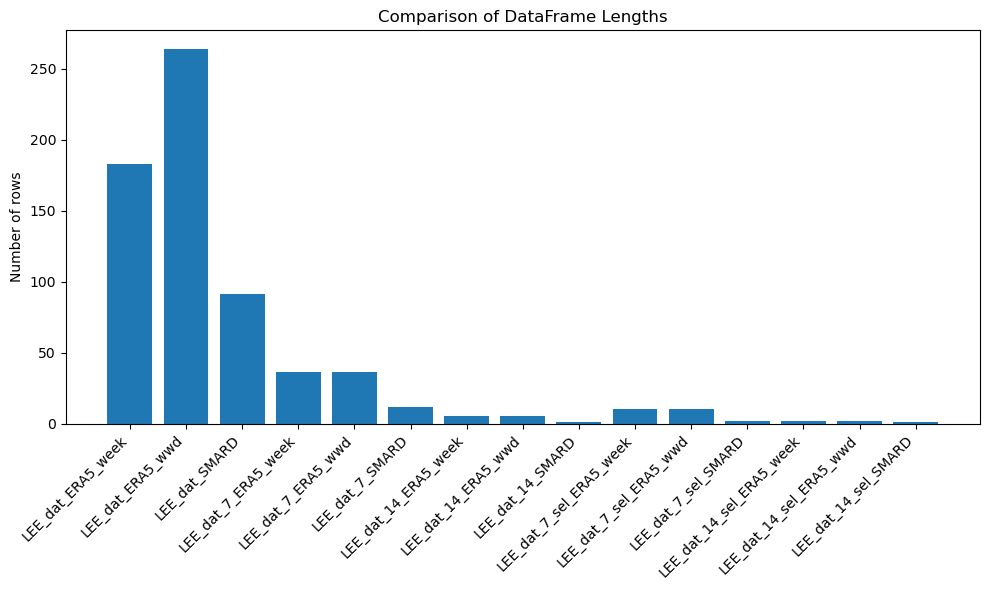

In [16]:
# build a dict of names → lengths
lengths = {
    'LEE_dat_ERA5_week':           len(LEE_dat_ERA5_week),
    'LEE_dat_ERA5_wwd':            len(LEE_dat_ERA5_wwd),
    'LEE_dat_SMARD':               len(LEE_dat_SMARD),
    'LEE_dat_7_ERA5_week':         len(LEE_dat_7_ERA5_week),
    'LEE_dat_7_ERA5_wwd':          len(LEE_dat_7_ERA5_wwd),
    'LEE_dat_7_SMARD':             len(LEE_dat_7_SMARD),
    'LEE_dat_14_ERA5_week':        len(LEE_dat_14_ERA5_week),
    'LEE_dat_14_ERA5_wwd':         len(LEE_dat_14_ERA5_wwd),
    'LEE_dat_14_SMARD':            len(LEE_dat_14_SMARD),
    'LEE_dat_7_sel_ERA5_week':     len(LEE_dat_7_sel_ERA5_week),
    'LEE_dat_7_sel_ERA5_wwd':      len(LEE_dat_7_sel_ERA5_wwd),
    'LEE_dat_7_sel_SMARD':         len(LEE_dat_7_sel_SMARD),
    'LEE_dat_14_sel_ERA5_week':    len(LEE_dat_14_sel_ERA5_week),
    'LEE_dat_14_sel_ERA5_wwd':     len(LEE_dat_14_sel_ERA5_wwd),
    'LEE_dat_14_sel_SMARD':        len(LEE_dat_14_sel_SMARD),
}

# plot
plt.figure(figsize=(10, 6))
plt.bar(lengths.keys(), lengths.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of rows')
plt.title('Comparison of DataFrame Lengths')
plt.tight_layout()
plt.show()


In [17]:
LEE_dat_ERA5_week

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9496,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1476.578114,1476.578114,0.0,1476.578114,9497,ERA5_week,ERA5_hist_week,2015,19
9497,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1492.586549,1492.586549,0.0,1492.586549,9498,ERA5_week,ERA5_hist_week,2015,20
9498,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1467.345044,1467.345044,0.0,1467.345044,9499,ERA5_week,ERA5_hist_week,2015,21
9499,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1439.511499,1439.511499,0.0,1439.511499,9500,ERA5_week,ERA5_hist_week,2015,22
9500,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1497.249011,1497.249011,0.0,1497.249011,9501,ERA5_week,ERA5_hist_week,2015,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9674,2024-12-12,2024-12-12,2024-12-12,3630,3630,3630,1,1491.259356,1491.259356,0.0,1491.259356,9675,ERA5_week,ERA5_hist_week,2024,346
9675,2024-12-13,2024-12-13,2024-12-13,3631,3631,3631,1,1473.156796,1473.156796,0.0,1473.156796,9676,ERA5_week,ERA5_hist_week,2024,347
9676,2024-12-26,2024-12-26,2024-12-26,3644,3644,3644,1,1443.400458,1443.400458,0.0,1443.400458,9677,ERA5_week,ERA5_hist_week,2024,360
9677,2024-12-27,2024-12-27,2024-12-27,3645,3645,3645,1,1486.131628,1486.131628,0.0,1486.131628,9678,ERA5_week,ERA5_hist_week,2024,361


In [18]:
LEE_dat_ERA5_wwd

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9679,2015-01-06,2015-01-06,2015-01-06,5,5,5,1,1428.972672,1428.972672,0.0,1428.972672,9680,ERA5_wwd,ERA5_hist_wwd,2015,6
9680,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1555.313425,1555.313425,0.0,1555.313425,9681,ERA5_wwd,ERA5_hist_wwd,2015,19
9681,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1571.298395,1571.298395,0.0,1571.298395,9682,ERA5_wwd,ERA5_hist_wwd,2015,20
9682,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1546.240039,1546.240039,0.0,1546.240039,9683,ERA5_wwd,ERA5_hist_wwd,2015,21
9683,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1518.320511,1518.320511,0.0,1518.320511,9684,ERA5_wwd,ERA5_hist_wwd,2015,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9938,2024-12-13,2024-12-13,2024-12-13,3631,3631,3631,1,1551.833395,1551.833395,0.0,1551.833395,9939,ERA5_wwd,ERA5_hist_wwd,2024,347
9939,2024-12-24,2024-12-24,2024-12-24,3642,3642,3642,1,1471.560130,1471.560130,0.0,1471.560130,9940,ERA5_wwd,ERA5_hist_wwd,2024,358
9940,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1418.954631,1418.954631,0.0,1418.954631,9941,ERA5_wwd,ERA5_hist_wwd,2024,359
9941,2024-12-26,2024-12-26,2024-12-26,3644,3644,3644,1,1521.253794,1521.253794,0.0,1521.253794,9942,ERA5_wwd,ERA5_hist_wwd,2024,360


In [19]:
LEE_dat_SMARD

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
18514,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1502.90425,1502.90425,0.0,1502.90425,18515,SMARD,SMARD_hist,2015,19
18515,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1567.50700,1567.50700,0.0,1567.50700,18516,SMARD,SMARD_hist,2015,20
18516,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1524.69225,1524.69225,0.0,1524.69225,18517,SMARD,SMARD_hist,2015,21
18517,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1529.50250,1529.50250,0.0,1529.50250,18518,SMARD,SMARD_hist,2015,22
18518,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1537.33700,1537.33700,0.0,1537.33700,18519,SMARD,SMARD_hist,2015,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.21775,1433.21775,0.0,1433.21775,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.19450,1446.19450,0.0,1446.19450,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.96600,1409.96600,0.0,1409.96600,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.07550,1425.07550,0.0,1425.07550,18604,SMARD,SMARD_hist,2024,345


In [20]:
# Which date_start are in LEE_dat_SMARD but not in  LEE_dat_ERA5_wwd
missing_dates = LEE_dat_SMARD['date_start'][~LEE_dat_SMARD['date_start'].isin(LEE_dat_ERA5_week['date_start'])]
missing_dates = LEE_dat_SMARD['date_start'][~LEE_dat_SMARD['date_start'].isin(LEE_dat_ERA5_wwd['date_start'])]

missing_dates

# What days of the week are in missing_dates?
# missing_days = pd.to_datetime(missing_dates).dt.day_name()
# missing_days

18523    2015-02-10
18526    2015-02-13
18528    2015-02-18
18555    2017-01-09
Name: date_start, dtype: object

In [21]:
# Which date_start are in LEE_dat_ERA5_wwd but not in LEE_dat_SMARD
missing_dates = LEE_dat_ERA5_week['date_start'][~LEE_dat_ERA5_week['date_start'].isin(LEE_dat_SMARD['date_start'])]
missing_dates = LEE_dat_ERA5_wwd['date_start'][~LEE_dat_ERA5_wwd['date_start'].isin(LEE_dat_SMARD['date_start'])]

len(missing_dates)

# What days of the week are in missing_dates?
# missing_days = pd.to_datetime(missing_dates).dt.day_name()
# missing_days

177

In [22]:
LEE_dat_ERA5_week[0:60]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9496,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1476.578114,1476.578114,0.0,1476.578114,9497,ERA5_week,ERA5_hist_week,2015,19
9497,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1492.586549,1492.586549,0.0,1492.586549,9498,ERA5_week,ERA5_hist_week,2015,20
9498,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1467.345044,1467.345044,0.0,1467.345044,9499,ERA5_week,ERA5_hist_week,2015,21
9499,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1439.511499,1439.511499,0.0,1439.511499,9500,ERA5_week,ERA5_hist_week,2015,22
9500,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1497.249011,1497.249011,0.0,1497.249011,9501,ERA5_week,ERA5_hist_week,2015,23
9501,2015-01-24,2015-01-24,2015-01-24,23,23,23,1,1417.618855,1417.618855,0.0,1417.618855,9502,ERA5_week,ERA5_hist_week,2015,24
9502,2015-01-30,2015-01-30,2015-01-30,29,29,29,1,1412.344556,1412.344556,0.0,1412.344556,9503,ERA5_week,ERA5_hist_week,2015,30
9503,2015-02-04,2015-02-04,2015-02-04,34,34,34,1,1449.191276,1449.191276,0.0,1449.191276,9504,ERA5_week,ERA5_hist_week,2015,35
9504,2015-02-11,2015-02-11,2015-02-11,41,41,41,1,1424.867738,1424.867738,0.0,1424.867738,9505,ERA5_week,ERA5_hist_week,2015,42
9505,2015-02-12,2015-02-12,2015-02-12,42,42,42,1,1423.050437,1423.050437,0.0,1423.050437,9506,ERA5_week,ERA5_hist_week,2015,43


In [23]:
LEE_dat_SMARD[60:]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
18574,2018-01-12,2018-01-12,2018-01-12,1106,1106,1106,1,1416.15425,1416.15425,0.0,1416.15425,18575,SMARD,SMARD_hist,2018,12
18575,2018-01-26,2018-01-26,2018-01-26,1120,1120,1120,1,1440.76200,1440.76200,0.0,1440.76200,18576,SMARD,SMARD_hist,2018,26
18576,2018-02-06,2018-02-06,2018-02-06,1131,1131,1131,1,1440.95500,1440.95500,0.0,1440.95500,18577,SMARD,SMARD_hist,2018,37
18577,2018-02-07,2018-02-07,2018-02-07,1132,1132,1132,1,1500.55500,1500.55500,0.0,1500.55500,18578,SMARD,SMARD_hist,2018,38
18578,2018-02-08,2018-02-08,2018-02-08,1133,1133,1133,1,1470.52475,1470.52475,0.0,1470.52475,18579,SMARD,SMARD_hist,2018,39
18579,2018-02-19,2018-02-19,2018-02-19,1144,1144,1144,1,1428.55925,1428.55925,0.0,1428.55925,18580,SMARD,SMARD_hist,2018,50
18580,2018-02-20,2018-02-20,2018-02-20,1145,1145,1145,1,1422.36225,1422.36225,0.0,1422.36225,18581,SMARD,SMARD_hist,2018,51
18581,2018-11-23,2018-11-23,2018-11-23,1421,1421,1421,1,1404.33475,1404.33475,0.0,1404.33475,18582,SMARD,SMARD_hist,2018,327
18582,2018-11-27,2018-11-27,2018-11-27,1425,1425,1425,1,1413.24100,1413.24100,0.0,1413.24100,18583,SMARD,SMARD_hist,2018,331
18583,2018-12-12,2018-12-12,2018-12-12,1440,1440,1440,1,1409.97300,1409.97300,0.0,1409.97300,18584,SMARD,SMARD_hist,2018,346


-----

### Read LEE data

In [24]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


---

### Check SMARD and ERA5_wwd data

In [25]:
LEE_dat_SMARD_ERA5 = LEE_dat = LEE_dat[(LEE_dat['ESM'] == 'SMARD') | (LEE_dat['ESM'] == 'ERA5_wwd')]
LEE_dat_SMARD = LEE_dat[(LEE_dat['ESM'] == 'SMARD')]
LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_wwd')]

LEE_7_SMARD_ERA5 = LEE_7[(LEE_7['ESM'] == 'SMARD') | (LEE_7['ESM'] == 'ERA5_wwd')]
LEE_7_SMARD = LEE_7[(LEE_7['ESM'] == 'SMARD')]
LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_wwd')]

LEE_14_SMARD_ERA5 = LEE_14[(LEE_14['ESM'] == 'SMARD') | (LEE_14['ESM'] == 'ERA5_wwd')]
LEE_14_SMARD = LEE_14[(LEE_14['ESM'] == 'SMARD')]
LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_wwd')] 

LEE_vl_SMARD_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'SMARD') | (LEE_vl['ESM'] == 'ERA5_wwd')]
LEE_vl_SMARD = LEE_vl[(LEE_vl['ESM'] == 'SMARD')]
LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_wwd')]

In [26]:
LEE_dat_SMARD

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
18514,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1502.90425,1502.90425,0.0,1502.90425,18515,SMARD,SMARD_hist,2015,19
18515,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1567.50700,1567.50700,0.0,1567.50700,18516,SMARD,SMARD_hist,2015,20
18516,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1524.69225,1524.69225,0.0,1524.69225,18517,SMARD,SMARD_hist,2015,21
18517,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1529.50250,1529.50250,0.0,1529.50250,18518,SMARD,SMARD_hist,2015,22
18518,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1537.33700,1537.33700,0.0,1537.33700,18519,SMARD,SMARD_hist,2015,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.21775,1433.21775,0.0,1433.21775,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.19450,1446.19450,0.0,1446.19450,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.96600,1409.96600,0.0,1409.96600,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.07550,1425.07550,0.0,1425.07550,18604,SMARD,SMARD_hist,2024,345


In [27]:
LEE_dat_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9679,2015-01-06,2015-01-06,2015-01-06,5,5,5,1,1428.972672,1428.972672,0.0,1428.972672,9680,ERA5_wwd,ERA5_hist_wwd,2015,6
9680,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1555.313425,1555.313425,0.0,1555.313425,9681,ERA5_wwd,ERA5_hist_wwd,2015,19
9681,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1571.298395,1571.298395,0.0,1571.298395,9682,ERA5_wwd,ERA5_hist_wwd,2015,20
9682,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1546.240039,1546.240039,0.0,1546.240039,9683,ERA5_wwd,ERA5_hist_wwd,2015,21
9683,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1518.320511,1518.320511,0.0,1518.320511,9684,ERA5_wwd,ERA5_hist_wwd,2015,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9938,2024-12-13,2024-12-13,2024-12-13,3631,3631,3631,1,1551.833395,1551.833395,0.0,1551.833395,9939,ERA5_wwd,ERA5_hist_wwd,2024,347
9939,2024-12-24,2024-12-24,2024-12-24,3642,3642,3642,1,1471.560130,1471.560130,0.0,1471.560130,9940,ERA5_wwd,ERA5_hist_wwd,2024,358
9940,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1418.954631,1418.954631,0.0,1418.954631,9941,ERA5_wwd,ERA5_hist_wwd,2024,359
9941,2024-12-26,2024-12-26,2024-12-26,3644,3644,3644,1,1521.253794,1521.253794,0.0,1521.253794,9942,ERA5_wwd,ERA5_hist_wwd,2024,360


In [28]:
# Check if there are any events which are in SMARD but not in ERA5
LEE_dat_SMARD_not_ERA5 = LEE_dat_SMARD[~LEE_dat_SMARD['date_start'].isin(LEE_dat_ERA5['date_start'])]
LEE_dat_SMARD_not_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
18523,2015-02-10,2015-02-10,2015-02-10,40,40,40,1,1421.89700,1421.89700,0.0,1421.89700,18524,SMARD,SMARD_hist,2015,41
18526,2015-02-13,2015-02-13,2015-02-13,43,43,43,1,1406.08625,1406.08625,0.0,1406.08625,18527,SMARD,SMARD_hist,2015,44
18528,2015-02-18,2015-02-18,2015-02-18,48,48,48,1,1421.28050,1421.28050,0.0,1421.28050,18529,SMARD,SMARD_hist,2015,49
18555,2017-01-09,2017-01-09,2017-01-09,738,738,738,1,1409.87075,1409.87075,0.0,1409.87075,18556,SMARD,SMARD_hist,2017,9


In [29]:
# Check if there are any events which are in SMARD but not in ERA5
LEE_dat_ERA5_not_SMARD = LEE_dat_ERA5[~LEE_dat_ERA5['date_start'].isin(LEE_dat_SMARD['date_start'])]
LEE_dat_ERA5_not_SMARD

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9679,2015-01-06,2015-01-06,2015-01-06,5,5,5,1,1428.972672,1428.972672,0.0,1428.972672,9680,ERA5_wwd,ERA5_hist_wwd,2015,6
9692,2015-02-27,2015-02-27,2015-02-27,57,57,57,1,1421.314950,1421.314950,0.0,1421.314950,9693,ERA5_wwd,ERA5_hist_wwd,2015,58
9693,2015-03-26,2015-03-26,2015-03-26,84,84,84,1,1409.720519,1409.720519,0.0,1409.720519,9694,ERA5_wwd,ERA5_hist_wwd,2015,85
9697,2015-11-02,2015-11-02,2015-11-02,305,305,305,1,1447.866696,1447.866696,0.0,1447.866696,9698,ERA5_wwd,ERA5_hist_wwd,2015,306
9698,2015-11-03,2015-11-03,2015-11-03,306,306,306,1,1453.340837,1453.340837,0.0,1453.340837,9699,ERA5_wwd,ERA5_hist_wwd,2015,307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9938,2024-12-13,2024-12-13,2024-12-13,3631,3631,3631,1,1551.833395,1551.833395,0.0,1551.833395,9939,ERA5_wwd,ERA5_hist_wwd,2024,347
9939,2024-12-24,2024-12-24,2024-12-24,3642,3642,3642,1,1471.560130,1471.560130,0.0,1471.560130,9940,ERA5_wwd,ERA5_hist_wwd,2024,358
9940,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1418.954631,1418.954631,0.0,1418.954631,9941,ERA5_wwd,ERA5_hist_wwd,2024,359
9941,2024-12-26,2024-12-26,2024-12-26,3644,3644,3644,1,1521.253794,1521.253794,0.0,1521.253794,9942,ERA5_wwd,ERA5_hist_wwd,2024,360


In [30]:
265-91+4

178

In [31]:
LEE_7_SMARD

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
1142,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000001,18,24,19,7,1567.50700,1432.481214,160.806691,10027.3685,1143,SMARD,SMARD_hist,2015,19
1143,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000005,748,754,753,7,1627.71375,1460.625714,148.305625,10224.3800,1144,SMARD,SMARD_hist,2017,19


In [32]:
LEE_7_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
560,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000004,18,24,22,7,1576.130226,1449.255278,166.516942,10144.786943,561,ERA5_wwd,ERA5_hist_wwd,2015,19
561,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1582.241563,1456.545834,118.653710,10195.820840,562,ERA5_wwd,ERA5_hist_wwd,2016,15
562,2016-12-14,2016-12-20,2016-12-14 00:00:00.000000005,712,718,717,7,1527.626235,1414.611065,108.457874,9902.277453,563,ERA5_wwd,ERA5_hist_wwd,2016,348
563,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1621.554132,1478.664747,121.031933,10350.653230,564,ERA5_wwd,ERA5_hist_wwd,2017,19
564,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1621.998147,1450.636331,136.206039,10154.454320,565,ERA5_wwd,ERA5_hist_wwd,2019,19
565,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1548.718814,1424.234213,127.582487,9969.639493,566,ERA5_wwd,ERA5_hist_wwd,2020,330
566,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1633.780190,1492.343873,130.361474,10446.407114,567,ERA5_wwd,ERA5_hist_wwd,2022,344
567,2023-01-20,2023-01-26,2023-01-20 00:00:00.000000000,2939,2945,2939,7,1581.416420,1411.084710,196.977838,9877.592971,568,ERA5_wwd,ERA5_hist_wwd,2023,20
568,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000002,2941,2947,2943,7,1535.547073,1417.878917,152.941319,9925.152419,569,ERA5_wwd,ERA5_hist_wwd,2023,22
569,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000003,3250,3256,3253,7,1592.943273,1449.659382,125.170210,10147.615672,570,ERA5_wwd,ERA5_hist_wwd,2023,331


In [33]:
# Check if there are any events which are in SMARD but not in ERA5
LEE_dat_SMARD_not_ERA5_7 = LEE_7_SMARD[~LEE_7_SMARD['date_start'].isin(LEE_7_ERA5['date_start'])]
LEE_dat_SMARD_not_ERA5_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy


In [34]:
LEE_14_SMARD

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
259,2017-01-15,2017-01-28,2017-01-15 00:00:00.000000009,744,757,753,14,1627.71375,1401.358429,176.227905,19619.018,260,SMARD,SMARD_hist,2017,15


In [35]:
LEE_14_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
104,2017-01-15,2017-01-28,2017-01-15 00:00:00.000000008,744,757,752,14,1621.554132,1419.605094,166.392554,19874.471321,105,ERA5_wwd,ERA5_hist_wwd,2017,15
105,2022-12-04,2022-12-17,2022-12-04 00:00:00.000000012,2892,2905,2904,14,1633.780190,1420.992226,180.251542,19893.891166,106,ERA5_wwd,ERA5_hist_wwd,2022,338


In [36]:
len(LEE_vl_SMARD)

50

In [37]:
LEE_vl_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5241,2015-01-06,2015-01-06,2015-01-06 00:00:00.000000000,5,5,5,1,1428.972672,1428.972672,0.000000,1428.972672,5242,ERA5_wwd,ERA5_hist_wwd,2015,6
5242,2015-01-19,2015-01-23,2015-01-19 00:00:00.000000004,18,22,22,5,1576.130226,1553.460519,20.603370,7767.302597,5243,ERA5_wwd,ERA5_hist_wwd,2015,19
5243,2015-01-30,2015-01-30,2015-01-30 00:00:00.000000000,29,29,29,1,1490.945844,1490.945844,0.000000,1490.945844,5244,ERA5_wwd,ERA5_hist_wwd,2015,30
5244,2015-02-03,2015-02-05,2015-02-03 00:00:00.000000001,33,35,34,3,1528.478732,1475.896733,37.877793,4427.690200,5245,ERA5_wwd,ERA5_hist_wwd,2015,34
5245,2015-02-11,2015-02-12,2015-02-11 00:00:00.000000000,41,42,41,2,1502.982243,1502.339371,0.642872,3004.678742,5246,ERA5_wwd,ERA5_hist_wwd,2015,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5386,2024-11-11,2024-11-13,2024-11-11 00:00:00.000000001,3599,3601,3600,3,1470.530233,1458.748136,9.610479,4376.244409,5387,ERA5_wwd,ERA5_hist_wwd,2024,315
5387,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1508.149164,1508.149164,0.000000,1508.149164,5388,ERA5_wwd,ERA5_hist_wwd,2024,333
5388,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1481.906900,1481.906900,0.000000,1481.906900,5389,ERA5_wwd,ERA5_hist_wwd,2024,338
5389,2024-12-11,2024-12-13,2024-12-11 00:00:00.000000001,3629,3631,3630,3,1569.629871,1562.641732,7.751304,4687.925196,5390,ERA5_wwd,ERA5_hist_wwd,2024,345
